# Non-Cartesian MRI Reconstruction with L1-Wavelet Compressed Sensing

This notebook demonstrates reconstruction of MRI images from **radially sampled** multi-coil k-space data using:

1. **Gridding reconstruction** (density-compensated adjoint NUFFT) -- a fast, non-iterative baseline
2. **L1-wavelet compressed sensing** -- iterative reconstruction with wavelet sparsity regularization

The key difference from standard Cartesian MRI reconstruction is that the forward model uses a **Non-Uniform FFT (NUFFT)** because the k-space samples lie on radial spokes rather than a regular grid.

## Forward Model

The multi-coil non-Cartesian MRI forward model maps a complex image $x \in \mathbb{C}^{H \times W}$ to k-space measurements:

$$y_c = \mathcal{F}_\text{NU}(S_c \cdot x) + \eta_c, \quad c = 1, \ldots, C$$

where $S_c$ is the sensitivity map for coil $c$, $\mathcal{F}_\text{NU}$ is the NUFFT evaluated at non-Cartesian k-space locations, and $\eta_c$ is noise.

## Reconstruction

The L1-wavelet CS reconstruction solves:

$$\hat{x} = \arg\min_x \; \frac{1}{2} \sum_c \|\mathcal{F}_\text{NU}(S_c x) - y_c\|_2^2 + \lambda \|\Psi x\|_1$$

where $\Psi$ is a wavelet transform and $\lambda$ controls regularization strength.

In [1]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Add task root to path
sys.path.insert(0, os.path.join(os.getcwd(), ".."))

from src.preprocessing import prepare_data
from src.physics_model import gridding_reconstruct, compute_density_compensation
from src.visualization import compute_metrics

## 1. Load Data

We load synthetically generated data: a 128x128 Shepp-Logan phantom with 4 birdcage receive coils and a golden-angle radial k-space trajectory (64 spokes, 128 readout points per spoke = 8,192 total k-space samples).

In [2]:
data_dir = os.path.join(os.getcwd(), "..", "data")
ref_dir = os.path.join(os.getcwd(), "..", "evaluation", "reference_outputs")

obs_data, ground_truth, metadata = prepare_data(data_dir)

kdata = obs_data["kdata"][0].astype(np.complex128)
coord = obs_data["coord"][0].astype(np.float64)
coil_maps = obs_data["coil_maps"][0].astype(np.complex128)
phantom = ground_truth[0].astype(np.complex128)
gt_mag = np.abs(phantom)

print(f"Image size: {gt_mag.shape}")
print(f"Number of coils: {coil_maps.shape[0]}")
print(f"k-space samples: {coord.shape[0]}")
print(f"Trajectory type: {metadata['trajectory_type']}")
print(f"Spokes: {metadata['n_spokes']}, Readout: {metadata['n_readout']}")

Image size: (128, 128)
Number of coils: 4
k-space samples: 8192
Trajectory type: golden_angle_radial
Spokes: 64, Readout: 128


## 2. Visualize Ground Truth and Sampling Pattern

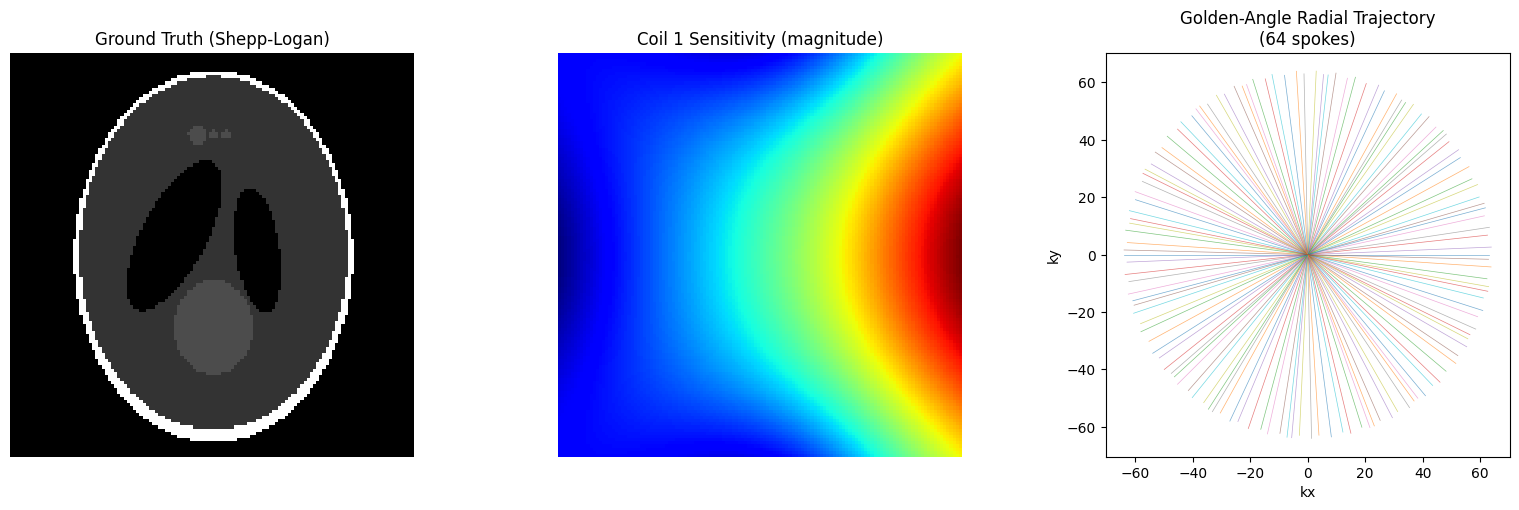

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Ground truth phantom
axes[0].imshow(gt_mag, cmap="gray")
axes[0].set_title("Ground Truth (Shepp-Logan)")
axes[0].axis("off")

# Coil sensitivity magnitudes (show first 2 coils)
coil_display = np.abs(coil_maps[0])
axes[1].imshow(coil_display, cmap="jet")
axes[1].set_title("Coil 1 Sensitivity (magnitude)")
axes[1].axis("off")

# Radial trajectory
n_spokes = metadata["n_spokes"]
n_readout = metadata["n_readout"]
for i in range(n_spokes):
    start = i * n_readout
    end = start + n_readout
    axes[2].plot(coord[start:end, 0], coord[start:end, 1], linewidth=0.5, alpha=0.6)
axes[2].set_aspect("equal")
axes[2].set_title(f"Golden-Angle Radial Trajectory\n({n_spokes} spokes)")
axes[2].set_xlabel("kx")
axes[2].set_ylabel("ky")

plt.tight_layout()
plt.show()

## 3. Load Precomputed Reconstructions

We load the precomputed gridding and L1-wavelet reconstructions from the reference outputs. To run the full reconstruction from scratch, uncomment the code below.

In [4]:
# Load precomputed results (runs in seconds)
grid_data = np.load(os.path.join(ref_dir, "gridding_reconstruction.npz"))
gridding_recon = grid_data["reconstruction"][0].astype(np.complex128)
gridding_mag = np.abs(gridding_recon)

l1wav_data = np.load(os.path.join(ref_dir, "l1wav_reconstruction.npz"))
l1wav_recon = l1wav_data["reconstruction"][0].astype(np.complex128)
l1wav_mag = np.abs(l1wav_recon)

# ---- Uncomment below to run from scratch ----
# from src.solvers import l1wav_reconstruct_single
#
# # Gridding reconstruction
# dcf = compute_density_compensation(coord, coil_maps.shape[1:], max_iter=30)
# gridding_recon = gridding_reconstruct(kdata, coord, coil_maps, dcf)
# gridding_mag = np.abs(gridding_recon)
#
# # L1-Wavelet CS reconstruction
# l1wav_recon = l1wav_reconstruct_single(kdata, coord, coil_maps, lamda=5e-5, max_iter=100)
# l1wav_mag = np.abs(l1wav_recon)

print("Loaded precomputed reconstructions.")

Loaded precomputed reconstructions.


## 4. Reconstruction Comparison

We compare the ground truth, gridding baseline, and L1-wavelet CS reconstruction side by side. The gridding result shows severe streaking artifacts from the non-uniform radial sampling, while L1-wavelet CS recovers a clean image.

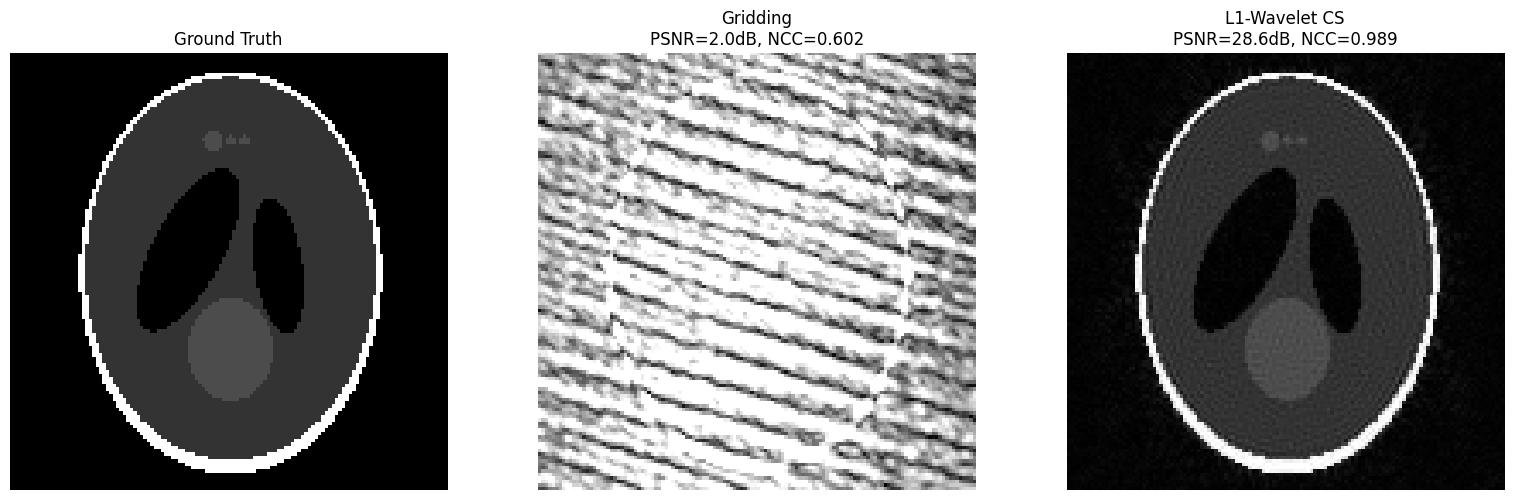

In [5]:
vmax = gt_mag.max()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(gt_mag, cmap="gray", vmin=0, vmax=vmax)
axes[0].set_title("Ground Truth")
axes[0].axis("off")

m_grid = compute_metrics(gridding_mag, gt_mag)
axes[1].imshow(gridding_mag, cmap="gray", vmin=0, vmax=vmax)
axes[1].set_title(f"Gridding\nPSNR={m_grid['psnr']:.1f}dB, NCC={m_grid['ncc']:.3f}")
axes[1].axis("off")

m_l1 = compute_metrics(l1wav_mag, gt_mag)
axes[2].imshow(l1wav_mag, cmap="gray", vmin=0, vmax=vmax)
axes[2].set_title(f"L1-Wavelet CS\nPSNR={m_l1['psnr']:.1f}dB, NCC={m_l1['ncc']:.3f}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 5. Error Maps

The error maps show the absolute difference between each reconstruction and the ground truth. The gridding error is dominated by streaking artifacts throughout the image, while the L1-wavelet error is much smaller and concentrated at edges.

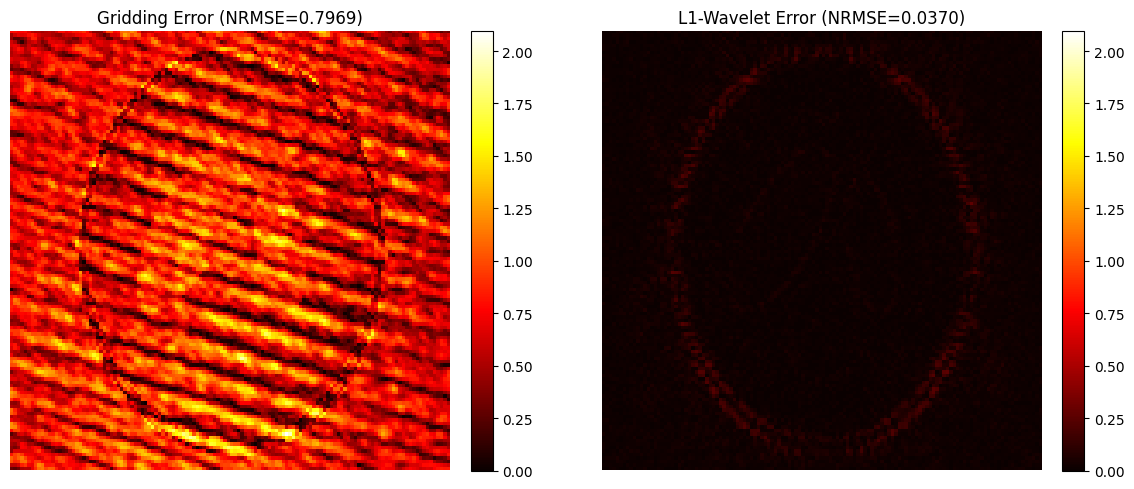

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

err_grid = np.abs(gt_mag - gridding_mag)
err_l1 = np.abs(gt_mag - l1wav_mag)
vmax_err = max(err_grid.max(), err_l1.max())

im0 = axes[0].imshow(err_grid, cmap="hot", vmin=0, vmax=vmax_err)
axes[0].set_title(f"Gridding Error (NRMSE={m_grid['nrmse']:.4f})")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(err_l1, cmap="hot", vmin=0, vmax=vmax_err)
axes[1].set_title(f"L1-Wavelet Error (NRMSE={m_l1['nrmse']:.4f})")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 6. Quantitative Metrics Summary

In [7]:
print(f"{'Method':>20s}  {'PSNR (dB)':>10s}  {'NCC':>8s}  {'NRMSE':>8s}")
print("-" * 52)
print(f"{'Gridding':>20s}  {m_grid['psnr']:>10.2f}  {m_grid['ncc']:>8.4f}  {m_grid['nrmse']:>8.4f}")
print(f"{'L1-Wavelet CS':>20s}  {m_l1['psnr']:>10.2f}  {m_l1['ncc']:>8.4f}  {m_l1['nrmse']:>8.4f}")
print()
print(f"L1-Wavelet improves PSNR by {m_l1['psnr'] - m_grid['psnr']:.1f} dB over gridding.")
print(f"L1-Wavelet reduces NRMSE by {(1 - m_l1['nrmse']/m_grid['nrmse'])*100:.1f}% relative to gridding.")

              Method   PSNR (dB)       NCC     NRMSE
----------------------------------------------------
            Gridding        1.97    0.6018    0.7969
       L1-Wavelet CS       28.64    0.9887    0.0370

L1-Wavelet improves PSNR by 26.7 dB over gridding.
L1-Wavelet reduces NRMSE by 95.4% relative to gridding.


## 7. Conclusion

The L1-wavelet compressed sensing reconstruction dramatically outperforms naive gridding for non-Cartesian MRI:

- **Gridding** (adjoint NUFFT with density compensation) is fast but produces severe streaking artifacts because it does not account for the ill-posedness of the inverse problem.
- **L1-wavelet CS** uses iterative optimization with a wavelet sparsity prior to suppress artifacts and recover fine structural detail, achieving NCC > 0.98 and NRMSE < 0.04.

The key computational component that distinguishes this from Cartesian CS-MRI is the **NUFFT** forward/adjoint pair, which handles the non-uniform k-space sampling geometry. The SigPy library provides efficient NUFFT implementations that make this tractable.